# Marketing Analytics: Customer Segmentation

**K-Means Clustering: Mall Customer Dataset**  
Applying unsupervised machine learning to segment customers by spending behavior and identify high-value groups.  
**Dataset:** [Mall Customer Segmentation](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

---

## Objectives

This project applies K-Means clustering to a mall customer dataset to identify distinct customer groups based on income and spending patterns. The goal is to move beyond demographic averages and surface actionable segments that a retail or marketing team can act on.

Key areas of focus:
- Use the Elbow Method to determine the optimal number of clusters
- Segment customers by Annual Income and Spending Score
- Profile each segment to identify high-value, at-risk, and opportunity groups
- Visualize cluster boundaries and produce a segment summary for business use

---

## Libraries, Directory & Data

The dataset consists of one CSV file (`Mall_Customers.csv`) containing 200 customer records with the following features:

- **CustomerID:** Unique identifier
- **Gender:** Male or Female
- **Age:** Customer age
- **Annual Income (k$):** Annual income in thousands
- **Spending Score (1–100):** Score assigned based on customer behavior and purchase history

## Libraries

In [1]:
#Install needed Libraries
import numpy as np
from scipy.stats import iqr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
#Load the data
customer_df = pd.read_csv('Mall_Customers.csv')
customer_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


We will start with the first five rows of our dataset using the **head()** function and later use the **describe()** function to output a statistical summary of it.

## Data Quality Check

Missing values in a clustering dataset can cause the model to either fail or produce unreliable segment assignments. Since K-Means clustering relies on distance calculations between data points, any gaps in the feature columns need to be identified before fitting the model.

We will need to check for any missing data.

In [3]:
customer_df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Statistical Summary

The describe() output gives a baseline view of each feature's distribution, the range of annual incomes, the spread of spending scores, and the age profile of the customer base. These figures help set expectations for what the segments will look like and confirm that the data falls within reasonable bounds before modeling begins.

We now use the **describe()** function to output a statistical summary of our data.

In [4]:
customer_df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [6]:
customer_df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [7]:
customer_df.shape

(200, 5)

## Outlier Detection

Outliers can pull cluster centroids toward extreme values, causing the model to form segments that don't reflect the majority of customers. Before fitting K-Means, it is important to identify any customers with unusually high income or spending scores that could distort the segmentation results.

Age: 


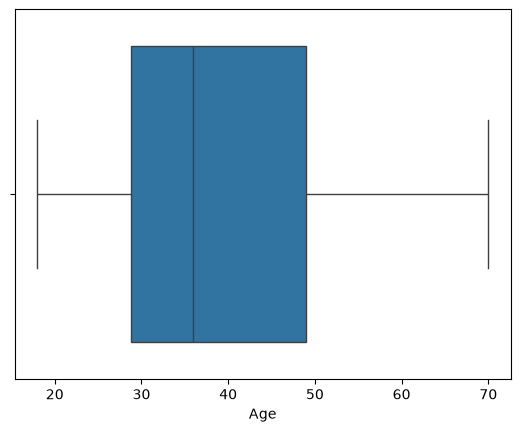

Annual Income (k$): 


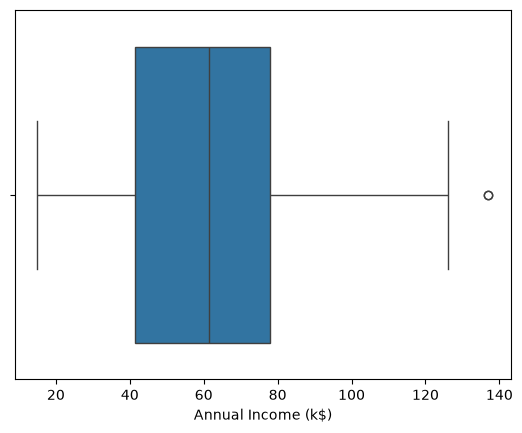

Spending Score (1-100): 


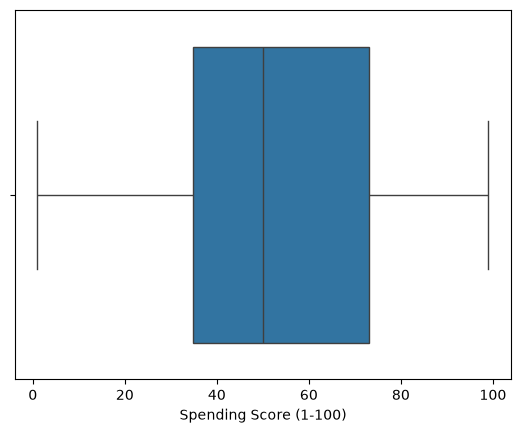

In [8]:
list1 = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for i in list1:
    print(str(i)+': ')
    ax = sns.boxplot(x=customer_df[str(i)])
    plt.show()

#Handling Outliers

Next we will need to remove the outliers from our data.

In [9]:
max_age = customer_df['Age'].quantile(0.99)
max_age

np.float64(69.00999999999999)

In [10]:
max_annual_income_k = customer_df['Annual Income (k$)'].quantile(0.99)
max_annual_income_k

np.float64(126.1099999999999)

In [11]:
max_spending_score = customer_df['Spending Score (1-100)'].quantile(0.99)
print(max_spending_score)

97.00999999999999


## Exploratory Data Analysis

Before applying any model, it helps to explore the individual features and how they relate to each other. This section works through univariate, bivariate, and multivariate analysis to build an intuition for where natural groupings might exist in the data, which the clustering model will later formalize.

## Univariate Analysis

Univariate analysis examines each feature independently to understand its distribution and typical range. For this dataset, the key question is how age, annual income, and spending score are distributed across the customer base, and whether any features are heavily skewed in a way that might affect how clusters form.

Univariate analysis entails evaluating a single feature to gain insights about it. So, the initial step in performing EDA is to undertake univariate analysis, which includes evaluating descriptive or summary statistics about the feature.

For example, check a feature distribution, the proportion of a feature, and so on.

In our case, we will check the dataset's distribution of customer's ages. We can do that by typing the following:

Text(0.5, 1.0, "Distribution of Customer's Age")

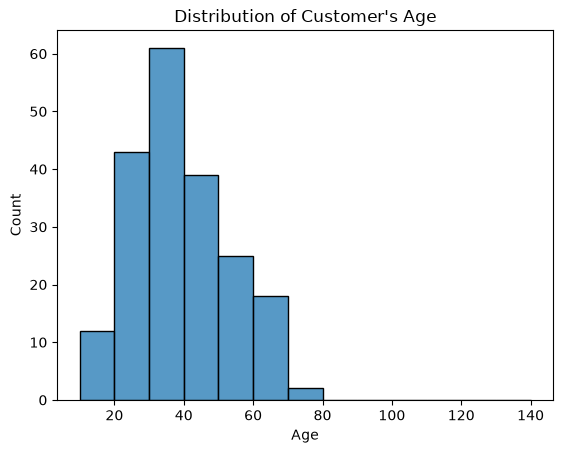

In [12]:
sns.histplot(customer_df, x="Age", bins = list(range(10, 150, 10)))
plt.title("Distribution of Customer's Age")

We can see from the above summary that most of the customers belong in the age range of 30 - 40.



## Bivariate Analysis

Bivariate analysis examines the relationship between two features at a time. Plotting Annual Income against Spending Score is particularly useful here because these are the two dimensions the K-Means model will use to form clusters. Visual groupings in this scatter plot give an early indication of how many natural segments exist in the data.

We performed a bivariate analysis, which usually involves the correlation of two attributes at the same time.

In our case, some of the bivariate analysis we'll perform in the project include observing the average total spent across different client age groups, determining a correlation between customer income and total spending, and so on, as shown below.

In [13]:
fig = px.scatter(customer_df, x="Annual Income (k$)",
                 y="Spending Score (1-100)",
                 title="Relationship Between Customer's Income and Spending",
                height=500,
                color_discrete_sequence = px.colors.qualitative.G10[1:])
fig.show()

## Multivariate Analysis

Adding Gender as a third dimension to the scatter plot reveals whether segment membership differs between male and female customers across income and spending levels. If the clusters align with gender, that has direct implications for how each segment should be addressed in campaign creative and channel selection.

After we've completed our univariate (analysis of single feature) and bivariate (analysis of two features) analysis, the last phase of our EDA is to perform a Multivariate Analysis.

This consists of understanding the relationship between two or more variables.

In our project, one of the multivariate analysis we'll do is to understand the relationship between Income, Spending Score, and Gender.

In [14]:
fig = px.scatter(
    data_frame=customer_df,
x = "Annual Income (k$)",
    y = "Spending Score (1-100)",
    facet_col = "Gender",
    title = "Relationship between Income VS Total Amount Spent Based on Age",
    color = "Age",
    height=500
)
fig.show()

We can see from the analysis that Male & Female customers between the ages of 60 to 70 years old generally spend less than other customers between the ages of 20 to 40.

This is because younger adults typically have higher disposable incomes compared to retirees. They are often in the early stages of their careers, earning regular salaries, and have fewer financial obligations such as mortgages, healthcare costs, or supporting dependents, which affects their spending habits.



## Segmentation Model

With the data explored and cleaned, the next step is to apply K-Means clustering to formally partition customers into segments based on Annual Income and Spending Score. K-Means groups data points by minimizing the distance between each point and its assigned cluster centroid, producing segments where customers within the same group are more similar to each other than to those in other groups.

##The Elbow Method

The elbow method is the strategy we'll use to select the best cluster. It works very well by plotting the error from each cluster and looking for a spot that forms an elbow on the plot.

As a result, the ideal cluster is the one that produces that elbow.

In [15]:
customer_df["Annual Income (k$)"].fillna(customer_df["Annual Income (k$)"].median(), inplace=True)

/tmp/ipykernel_3999/3240304872.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  customer_df["Annual Income (k$)"].fillna(customer_df["Annual Income (k$)"].median(), inplace=True)


0       15
1       15
2       16
3       16
4       17
      ... 
195    120
196    126
197    126
198    137
199    137
Name: Annual Income (k$), Length: 200, dtype: int64

In [16]:
data = customer_df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [17]:
df_log = np.log(data)

In [18]:
std_scaler = StandardScaler()
df_scaled = std_scaler.fit_transform(df_log)

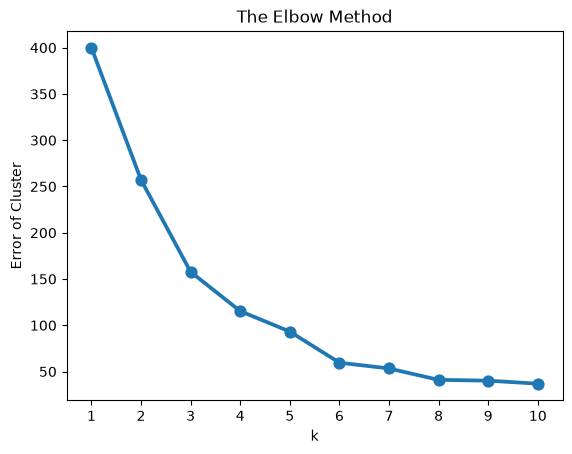

In [19]:
errors = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df_scaled)
    errors.append(model.inertia_)


plt.title('The Elbow Method')
plt.xlabel('k'); plt.ylabel('Error of Cluster')
sns.pointplot(x=list(range(1, 11)), y=errors)
plt.show()

Let's summarize what the above code does. We specified the number of clusters to experiment with in the **range(1, 11)**. Then, we fit the features on those clusters and added the error to the list we created above.

Following that, we plot the error for each cluster. The diagram shows that the cluster that creates the elbow is three. So, three clusters is the best value for our model. As a result, we will build the **KMeans** model utilizing three clusters.

In [20]:
model = KMeans(n_clusters = 3, random_state=42)
model.fit(df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[

In [21]:
data = data.assign(ClusterLabel = model.labels_)

Now we've built our model. The next thing will be to assign the cluster label for each observation. So we will assign the label to the original feature we didn't processed. That is, where we assigned Annual Income and Spending Score  to the variable data

Now that we've built the model, the next step is to interpret the results from each cluster.

Depending on your goals, there are numerous ways to summarize your cluster's results. The most common summary uses central tendency, which includes mean, median, and mode.

For our case, we will use the median. We're using the median because the original features have outliers, and the mean is very sensitive to outliers.

Our next step involves aggregating the cluster labels and finding the median for Annual Income and Spending Score. We will achieve this using the Pandas groupby method. This method allows us to group the data by the cluster labels and then calculate the median for each group. The result is a clear and concise summary of the data, facilitating our interpretation of the results.

In [22]:
data.groupby("ClusterLabel")[["Annual Income (k$)", "Spending Score (1-100)"]].median()

,Annual Income (k$),Spending Score (1-100)
ClusterLabel,,
0,63.0,55.0
1,81.0,13.0
2,23.5,39.5


Based on the median values, the three clusters break down as follows:

* **Cluster 0** — Moderate-to-high income (63k), moderate spending score (55). Mid-range customers who earn reasonably well and spend at a moderate rate.
* **Cluster 1** — Highest income (81k), lowest spending score (13). High earners who spend conservatively, possibly prioritizing savings over consumption.
* **Cluster 2** — Lowest income (23.5k), moderate-low spending score (39.5). Budget-constrained customers with limited purchasing power.

In [23]:
fig = px.scatter(
    data_frame=data,
    x = "Spending Score (1-100)",
    y= "Annual Income (k$)",
    title = "Relationship between Income VS Total Amount Spent",
    color = "ClusterLabel",
    height=500
)
fig.show()

In [24]:
data = customer_df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
df_log = np.log(data)
std_scaler = StandardScaler()
df_scaled = std_scaler.fit_transform(df_log)

In [25]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 3)","[

In [26]:
customer_df = data.assign(ClusterLabel= model.labels_)

In [27]:
customer_df.groupby("ClusterLabel").agg({"Age":"mean", "Annual Income (k$)":"median", "Spending Score (1-100)":"median"}).round()

,Age,Annual Income (k$),Spending Score (1-100)
ClusterLabel,,,
0,52.0,58.0,41.0
1,30.0,74.0,60.0
2,27.0,24.0,73.0


The three-feature model (Age, Income, Spending Score) produces the following segment profiles:

* **Cluster 0** — Avg age 52, income 58k, spending score 41. Middle-aged customers with moderate income and moderate spending behavior.
* **Cluster 1** — Avg age 30, income 74k, spending score 60. Younger, higher-income customers with a stronger propensity to spend, likely in prime earning and spending years.
* **Cluster 2** — Avg age 27, income 24k, spending score 73. Young customers with low income but a high spending score, possibly financed by credit or representing lifestyle-first spending patterns.

## 3D Cluster Visualization

Adding Age as a third dimension to the scatter plot provides a richer view of how the segments differ across all three features simultaneously. While the K-Means model was trained on Income and Spending Score, overlaying Age reveals whether the clusters also map onto distinct life stages, which has direct implications for how each segment should be approached in a marketing context.

In [28]:
fig = px.scatter_3d(customer_df, x="Annual Income (k$)",
                    y="Spending Score (1-100)", z="Age", color="ClusterLabel", height=550,
                   title = "Visualizing Cluster Result Using 3 Features")
fig.show()